# Phase 1: Egypt Climatology & Solar Potential Clustering Analysis
## Unsupervised Learning Pipeline: Feature Selection, Yeo-Johnson Power Transformation, PCA Dimensionality Reduction, K-Means & Hierarchical Clustering

**Project Goal**: Analyze NASA POWER climatology data for 377 grid locations across Egypt. Create a clean copy of the dataset containing only the essential annual features (`latitude`, `longitude`, `ALLSKY_SFC_SW_DWN_ANN`, `RH2M_ANN`, `T2M_ANN`, `WS2M_ANN`) while dropping unnecessary monthly columns. Apply **PowerTransformer (Yeo-Johnson)** for skewness correction and standardization, and **Principal Component Analysis (PCA)** to eliminate feature correlation (multicollinearity), evaluate optimal cluster count $K$ via Elbow Method and Silhouette Analysis, perform Grid Search fine-tuning for K-Means and Hierarchical Clustering, compare model performance, map clusters geographically across Egypt, and recommend the optimal region for solar power generation projects.


## 1. Environment Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Plotting style configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
print('Libraries imported successfully!')


Libraries imported successfully!


## 2. Data Loading & Creating Clean Dataset Copy
We load the raw climatology dataset and create a clean copy (`df_clean`) retaining only the core annual climate features and coordinates while dropping all 48 monthly columns (`_JAN` through `_DEC`).


In [2]:
# Load raw dataset
df_raw = pd.read_csv('egypt_climatology_full.csv')
print(f"Raw Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# Select core columns and create a clean copy
core_cols = ['latitude', 'longitude', 'ALLSKY_SFC_SW_DWN_ANN', 'RH2M_ANN', 'T2M_ANN', 'WS2M_ANN']
df_clean = df_raw[core_cols].copy()

print(f"\nCleaned Dataset Shape (Monthly columns dropped): {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"Missing Values: {df_clean.isnull().sum().sum()}")
print(f"Duplicate Rows: {df_clean.duplicated().sum()}")
print("\nFirst 5 rows of df_clean:")
df_clean.head()


Raw Dataset Shape: 377 rows, 54 columns

Cleaned Dataset Shape (Monthly columns dropped): 377 rows, 6 columns
Missing Values: 0
Duplicate Rows: 0

First 5 rows of df_clean:


,latitude,longitude,ALLSKY_SFC_SW_DWN_ANN,RH2M_ANN,T2M_ANN,WS2M_ANN
0,22.0,25.0,6.7795,24.30,22.93,2.85
1,22.0,25.5,6.7795,25.83,22.10,2.82
2,22.0,26.0,6.7493,26.28,22.31,2.73
3,22.0,26.5,6.7493,26.28,22.31,2.73
4,22.0,27.0,6.6991,26.41,22.65,2.89


In [3]:
print("--- Cleaned Dataset Information ---")
print(df_clean.info())

print("\n--- Statistical Summary of Core Annual Parameters ---")
df_clean.describe()


--- Cleaned Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   latitude               377 non-null    float64
 1   longitude              377 non-null    float64
 2   ALLSKY_SFC_SW_DWN_ANN  377 non-null    float64
 3   RH2M_ANN               377 non-null    float64
 4   T2M_ANN                377 non-null    float64
 5   WS2M_ANN               377 non-null    float64
dtypes: float64(6)
memory usage: 17.8 KB
None

--- Statistical Summary of Core Annual Parameters ---


,latitude,longitude,ALLSKY_SFC_SW_DWN_ANN,RH2M_ANN,T2M_ANN,WS2M_ANN
count,377.000000,377.000000,377.000000,377.000000,377.000000,377.000000
mean,26.424403,29.697613,6.298556,37.571538,22.558037,3.137851
std,2.780343,2.913435,0.324291,11.149699,2.028518,0.316272
min,22.000000,25.000000,5.199600,23.690000,18.390000,2.520000
25%,24.000000,27.000000,6.139700,28.040000,21.290000,2.920000
50%,26.500000,29.500000,6.366200,34.480000,22.040000,3.130000
75%,29.000000,32.000000,6.541400,44.190000,23.940000,3.320000
max,31.500000,35.000000,6.779500,69.470000,27.700000,5.070000


## 3. Exploratory Data Analysis (EDA)
Using `df_clean`, we evaluate feature distributions, skewness, outliers, correlations, and geospatial patterns across Egypt.


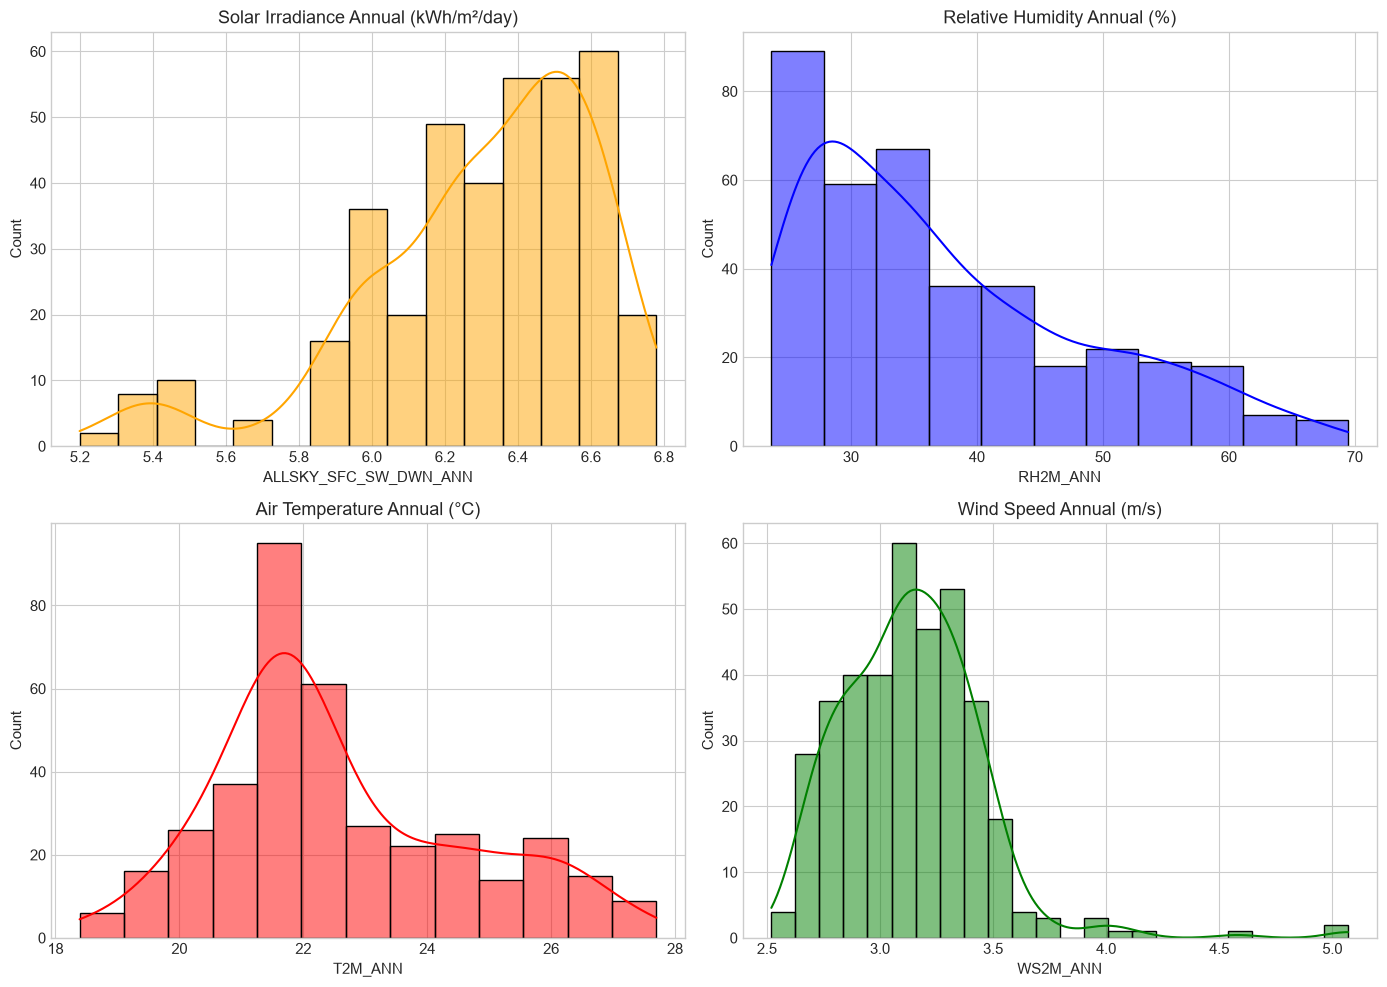

--- Skewness Values ---
WS2M_ANN                 1.600687
RH2M_ANN                 0.864838
T2M_ANN                  0.591997
ALLSKY_SFC_SW_DWN_ANN   -1.166007
dtype: float64


In [4]:
# Distributions of core annual climate variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_clean['ALLSKY_SFC_SW_DWN_ANN'], kde=True, ax=axes[0, 0], color='orange')
axes[0, 0].set_title('Solar Irradiance Annual (kWh/m²/day)')

sns.histplot(df_clean['RH2M_ANN'], kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Relative Humidity Annual (%)')

sns.histplot(df_clean['T2M_ANN'], kde=True, ax=axes[1, 0], color='red')
axes[1, 0].set_title('Air Temperature Annual (°C)')

sns.histplot(df_clean['WS2M_ANN'], kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Wind Speed Annual (m/s)')

plt.tight_layout()
plt.show()

# Skewness Calculation
skewness = df_clean[['ALLSKY_SFC_SW_DWN_ANN', 'RH2M_ANN', 'T2M_ANN', 'WS2M_ANN']].skew()
print("--- Skewness Values ---")
print(skewness.sort_values(ascending=False))


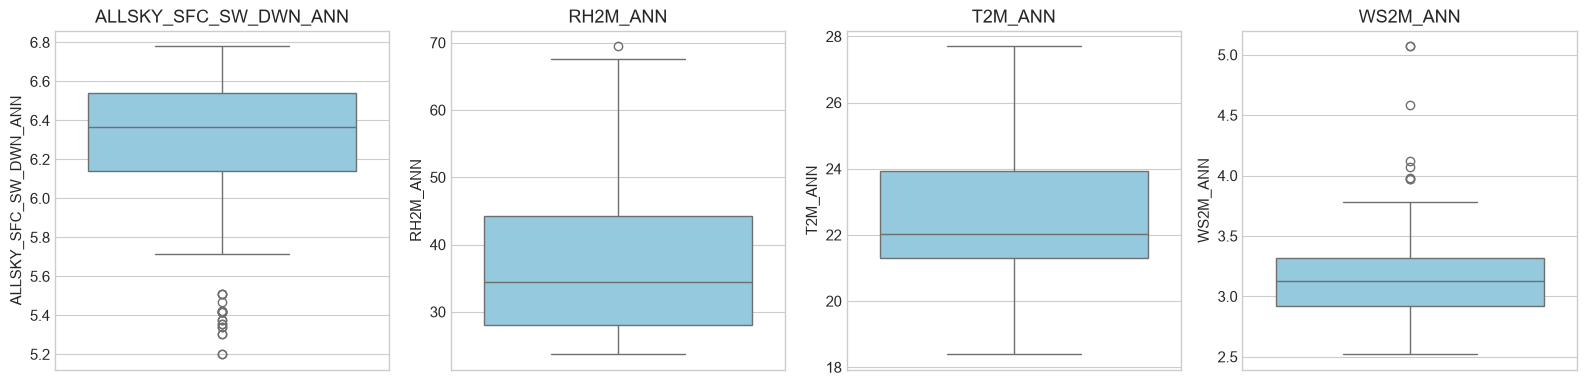

In [5]:
# Outlier detection using Boxplots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['ALLSKY_SFC_SW_DWN_ANN', 'RH2M_ANN', 'T2M_ANN', 'WS2M_ANN']

for i, col in enumerate(cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


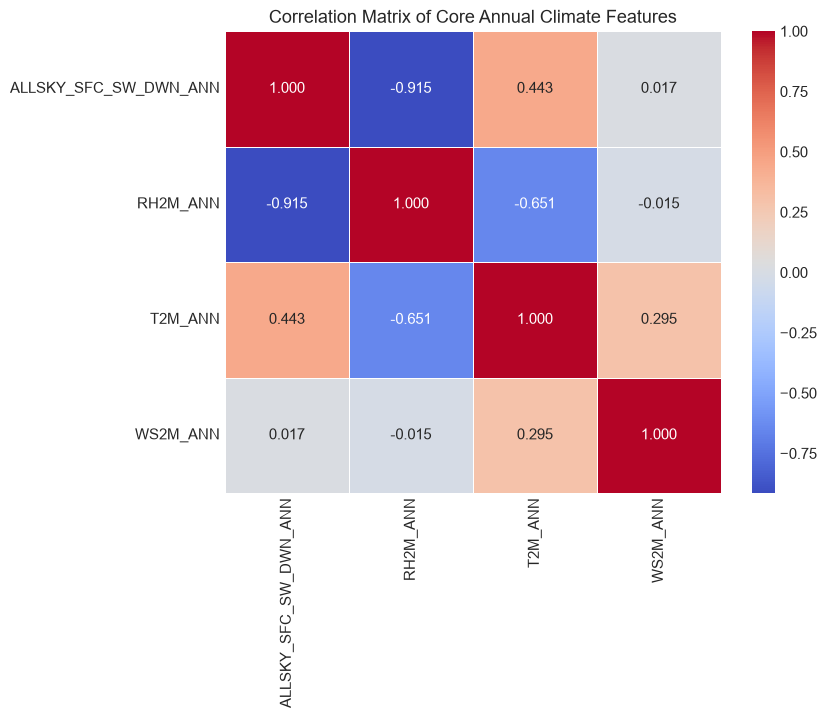

In [6]:
# Correlation matrix heatmap
plt.figure(figsize=(8, 6))
corr = df_clean[['ALLSKY_SFC_SW_DWN_ANN', 'RH2M_ANN', 'T2M_ANN', 'WS2M_ANN']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix of Core Annual Climate Features')
plt.show()


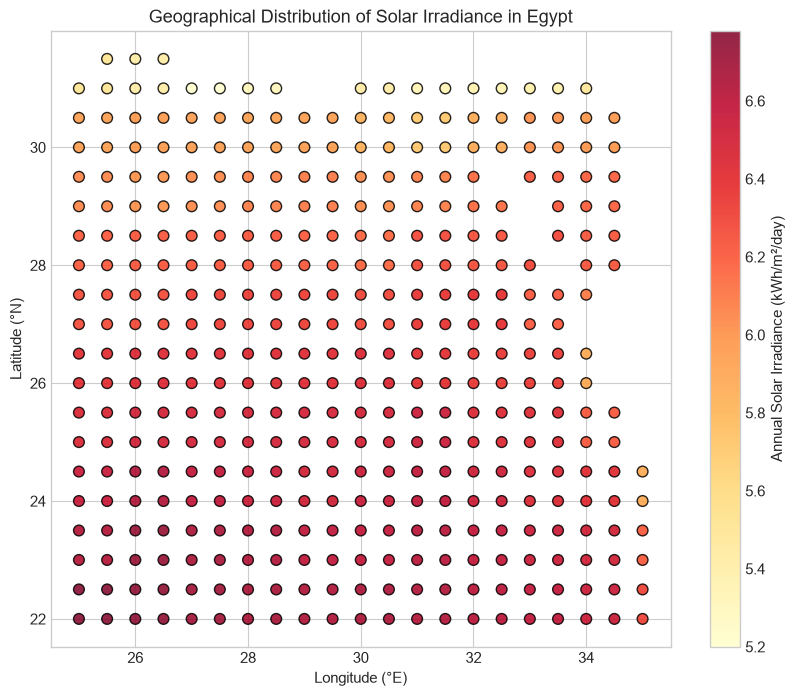

In [7]:
# Geospatial plot of Egypt coordinates colored by Annual Solar Irradiance
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_clean['longitude'], df_clean['latitude'], c=df_clean['ALLSKY_SFC_SW_DWN_ANN'], cmap='YlOrRd', s=60, edgecolors='k', alpha=0.85)
plt.colorbar(scatter, label='Annual Solar Irradiance (kWh/m²/day)')
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Geographical Distribution of Solar Irradiance in Egypt')
plt.show()


## 4. Preprocessing, Yeo-Johnson Transformation & PCA
1. We extract feature matrix $X$ from `df_clean` (`ALLSKY_SFC_SW_DWN_ANN`, `RH2M_ANN`, `T2M_ANN`, `WS2M_ANN`).
2. We **DROP** `latitude` and `longitude` from input matrix $X$ so clustering is driven purely by atmospheric and solar attributes.
3. We apply **PowerTransformer (Yeo-Johnson)** to correct skewness and standardize features (mean = 0, std = 1).
4. We apply **Principal Component Analysis (PCA)** to eliminate feature correlation (multicollinearity) between variables ($r = 0.00$ between principal components).


--- Skewness Values After Yeo-Johnson Transform ---
RH2M_ANN                 0.114132
T2M_ANN                  0.021982
WS2M_ANN                 0.006822
ALLSKY_SFC_SW_DWN_ANN   -0.125256
dtype: float64

Original Feature Count: 4
PCA Reduced Dimensions: 3
Explained Variance Ratio per Component: [0.6192 0.2472 0.1239]
Total Cumulative Variance Retained: 99.03%


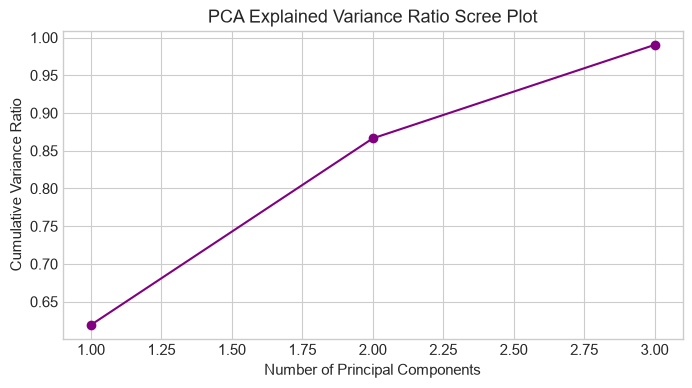

In [8]:
# Feature Matrix Selection from df_clean
feature_cols = ['ALLSKY_SFC_SW_DWN_ANN', 'RH2M_ANN', 'T2M_ANN', 'WS2M_ANN']
X = df_clean[feature_cols].copy()

# Outlier Capping (IQR Capping as per part1.ipynb logic)
for col in feature_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X[col] = X[col].clip(lower_bound, upper_bound)

# Apply PowerTransformer (Yeo-Johnson) for Skewness Correction and Scaling
pt = PowerTransformer(method='yeo-johnson')
X_trans = pt.fit_transform(X)

X_trans_df = pd.DataFrame(X_trans, columns=feature_cols)
print("--- Skewness Values After Yeo-Johnson Transform ---")
print(X_trans_df.skew().sort_values(ascending=False))

# Dimensionality Reduction via PCA
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_trans)

print(f"\nOriginal Feature Count: {X_trans.shape[1]}")
print(f"PCA Reduced Dimensions: {X_pca.shape[1]}")
print(f"Explained Variance Ratio per Component: {pca.explained_variance_ratio_.round(4)}")
print(f"Total Cumulative Variance Retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Scree Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='purple')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Ratio')
plt.title('PCA Explained Variance Ratio Scree Plot')
plt.grid(True)
plt.show()


## 5. K-Means Clustering & Hyperparameter Fine-Tuning
We determine the optimal number of clusters $K$ using:
- **Elbow Method** (Inertia plot across $K \in [1, 10]$).
- **Silhouette Analysis** (Scores across $K \in [2, 8]$).
- **Grid Search Fine-Tuning** (`n_clusters`, `init`, `n_init`, `max_iter`).


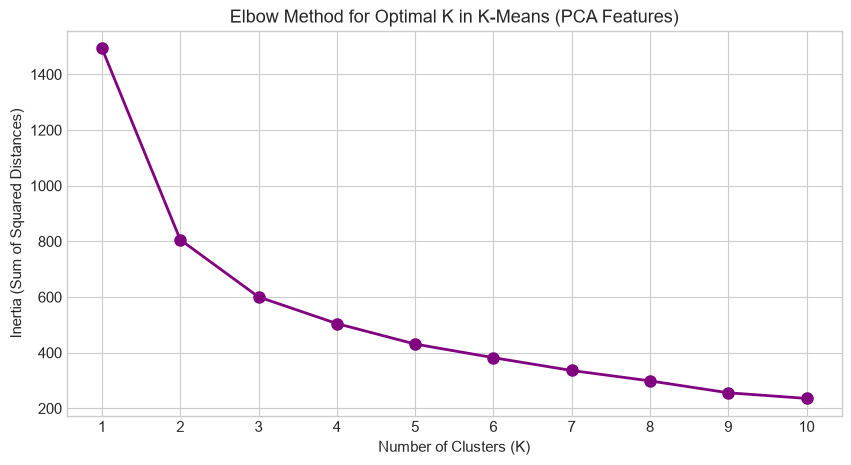

K-Means k=2 -> Silhouette Score = 0.4015
K-Means k=3 -> Silhouette Score = 0.3422
K-Means k=4 -> Silhouette Score = 0.3045
K-Means k=5 -> Silhouette Score = 0.3153
K-Means k=6 -> Silhouette Score = 0.3209
K-Means k=7 -> Silhouette Score = 0.3306
K-Means k=8 -> Silhouette Score = 0.3265

=== Best K-Means Grid Search Results ===
Optimal Parameters: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 10}
Best Silhouette Score: 0.4015


In [9]:
# Elbow Method on PCA features
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='purple', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal K in K-Means (PCA Features)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Silhouette Score Evaluation
silhouette_scores_km = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores_km.append((k, score))
    print(f"K-Means k={k} -> Silhouette Score = {score:.4f}")

# Grid Search Fine-Tuning for K-Means
best_km_score = -1
best_km_params = None
best_km_model = None

for k in [2, 3, 4, 5]:
    for init in ['k-means++', 'random']:
        for n_init in [10, 20, 30]:
            km = KMeans(n_clusters=k, init=init, n_init=n_init, max_iter=300, random_state=42)
            labels = km.fit_predict(X_pca)
            score = silhouette_score(X_pca, labels)
            if score > best_km_score:
                best_km_score = score
                best_km_params = {'n_clusters': k, 'init': init, 'n_init': n_init}
                best_km_model = km

print("\n=== Best K-Means Grid Search Results ===")
print(f"Optimal Parameters: {best_km_params}")
print(f"Best Silhouette Score: {best_km_score:.4f}")

df_clean['KMeans_Cluster'] = best_km_model.labels_


## 6. Hierarchical Agglomerative Clustering & Fine-Tuning
We construct a hierarchical dendrogram using `scipy.cluster.hierarchy` and evaluate optimal linkage methods (`ward`, `complete`, `average`) on PCA components.


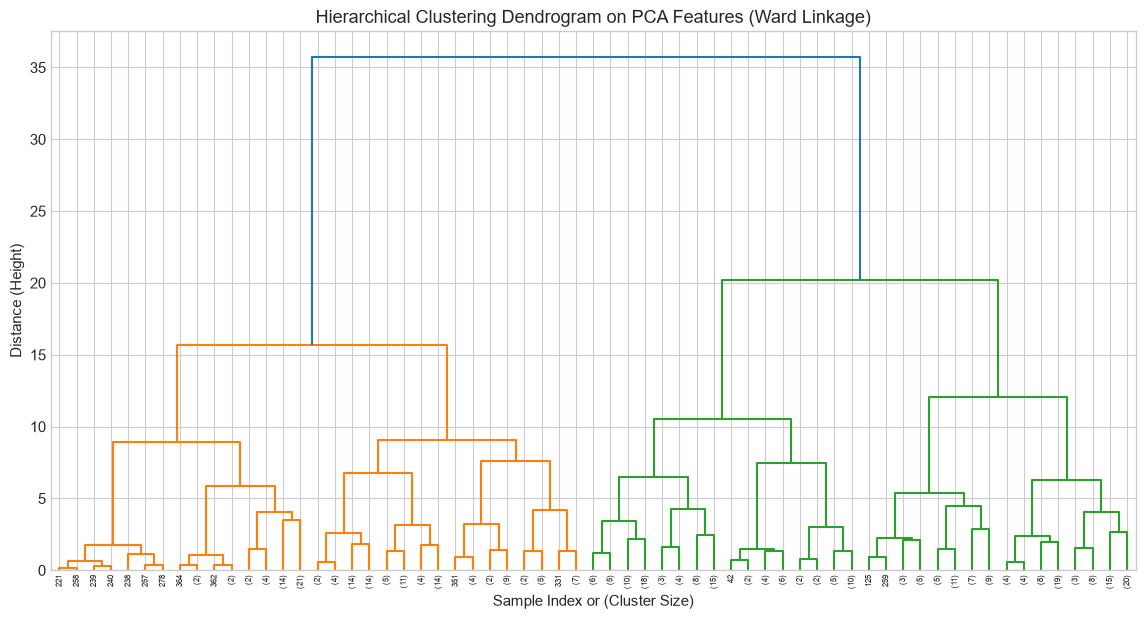

=== Best Hierarchical Clustering Grid Search Results ===
Optimal Parameters: {'n_clusters': 2, 'linkage': 'ward'}
Best Silhouette Score: 0.3689


In [10]:
# Hierarchical Dendrogram using Ward Linkage on PCA
plt.figure(figsize=(14, 7))
linkage_matrix = linkage(X_pca, method='ward', metric='euclidean')
dendrogram(linkage_matrix, truncate_mode='level', p=5, show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram on PCA Features (Ward Linkage)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance (Height)')
plt.show()

# Grid Search Fine-Tuning for Hierarchical Clustering
best_agg_score = -1
best_agg_params = None
best_agg_model = None

for k in [2, 3, 4, 5]:
    for link in ['ward', 'complete', 'average']:
        agg = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = agg.fit_predict(X_pca)
        score = silhouette_score(X_pca, labels)
        if score > best_agg_score:
            best_agg_score = score
            best_agg_params = {'n_clusters': k, 'linkage': link}
            best_agg_model = agg

print("=== Best Hierarchical Clustering Grid Search Results ===")
print(f"Optimal Parameters: {best_agg_params}")
print(f"Best Silhouette Score: {best_agg_score:.4f}")

df_clean['Hierarchical_Cluster'] = best_agg_model.labels_


## 7. Model Performance Comparison
We compare **K-Means** vs **Hierarchical Agglomerative Clustering** using `df_clean`:
1. **Silhouette Score** (Higher is better, range [-1, 1]).
2. **Calinski-Harabasz Index** (Higher is better).
3. **Davies-Bouldin Index** (Lower is better).


=== Model Performance Comparison ===
                                 Metric  K-Means (PCA)  Hierarchical Clustering (PCA)
       Silhouette Score (Higher Better)         0.4015                         0.3689
Calinski-Harabasz Index (Higher Better)       319.9141                       280.0728
    Davies-Bouldin Index (Lower Better)         0.9794                         1.0460


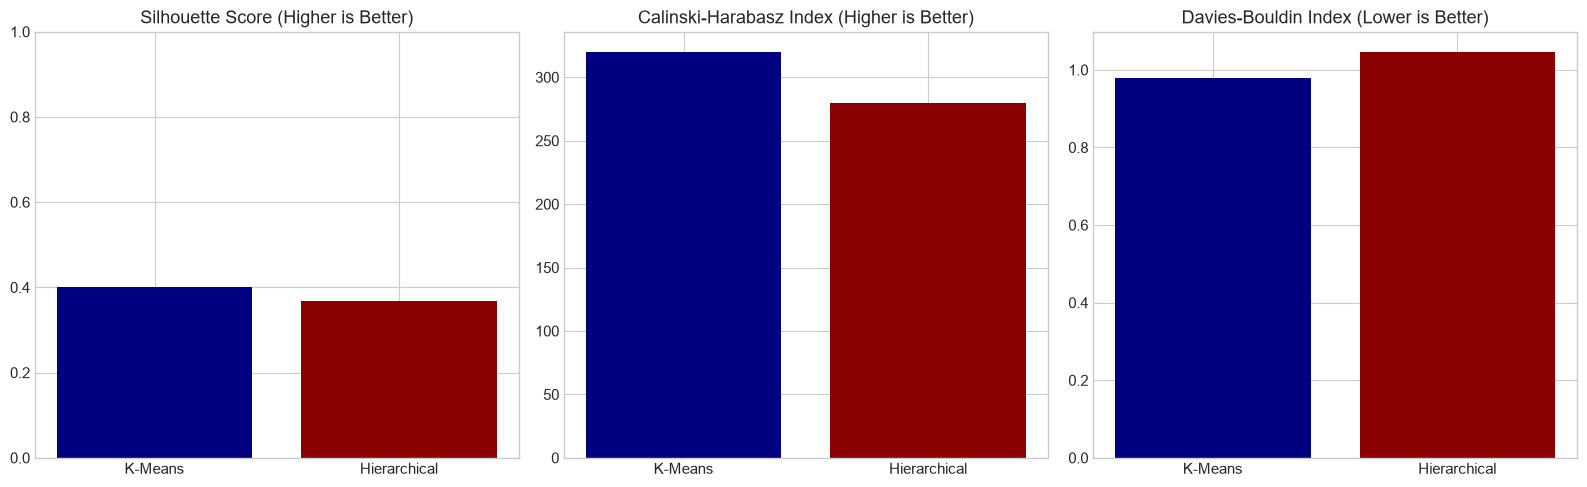


Best Performing Clustering Model: K-Means


In [11]:
km_labels = df_clean['KMeans_Cluster']
agg_labels = df_clean['Hierarchical_Cluster']

km_sil = silhouette_score(X_pca, km_labels)
agg_sil = silhouette_score(X_pca, agg_labels)

km_ch = calinski_harabasz_score(X_pca, km_labels)
agg_ch = calinski_harabasz_score(X_pca, agg_labels)

km_db = davies_bouldin_score(X_pca, km_labels)
agg_db = davies_bouldin_score(X_pca, agg_labels)

comparison_df = pd.DataFrame({
    'Metric': ['Silhouette Score (Higher Better)', 'Calinski-Harabasz Index (Higher Better)', 'Davies-Bouldin Index (Lower Better)'],
    'K-Means (PCA)': [km_sil, km_ch, km_db],
    'Hierarchical Clustering (PCA)': [agg_sil, agg_ch, agg_db]
})

print("=== Model Performance Comparison ===")
print(comparison_df.round(4).to_string(index=False))

# Bar Chart Comparison
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].bar(['K-Means', 'Hierarchical'], [km_sil, agg_sil], color=['navy', 'darkred'])
ax[0].set_title('Silhouette Score (Higher is Better)')
ax[0].set_ylim(0, 1)

ax[1].bar(['K-Means', 'Hierarchical'], [km_ch, agg_ch], color=['navy', 'darkred'])
ax[1].set_title('Calinski-Harabasz Index (Higher is Better)')

ax[2].bar(['K-Means', 'Hierarchical'], [km_db, agg_db], color=['navy', 'darkred'])
ax[2].set_title('Davies-Bouldin Index (Lower is Better)')

plt.tight_layout()
plt.show()

# Select the model with the highest Silhouette score
winning_model = "K-Means" if km_sil >= agg_sil else "Hierarchical Clustering"
df_clean['Cluster'] = df_clean['KMeans_Cluster'] if km_sil >= agg_sil else df_clean['Hierarchical_Cluster']
print(f"\nBest Performing Clustering Model: {winning_model}")


## 8. Cluster Profiling, Geospatial Mapping & Optimal Solar Site Selection
Now we map the winning cluster labels back to `latitude` and `longitude` in `df_clean` to analyze the physical solar power potential across Egyptian geographical zones.


In [12]:
# Group mean profiles per cluster using df_clean
cluster_profile = df_clean.groupby('Cluster')[feature_cols].mean()

print("=== Cluster Means Profile ===")
print(cluster_profile.round(3))

print("\n=== Cluster Count Distribution ===")
print(df_clean['Cluster'].value_counts().sort_index())


=== Cluster Means Profile ===
         ALLSKY_SFC_SW_DWN_ANN  RH2M_ANN  T2M_ANN  WS2M_ANN
Cluster                                                    
0                        6.526    28.825   24.123     3.275
1                        6.108    44.910   21.245     3.022

=== Cluster Count Distribution ===
Cluster
0    172
1    205
Name: count, dtype: int64


C:\Users\ZBook\AppData\Local\Temp\ipykernel_24196\1819795503.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='ALLSKY_SFC_SW_DWN_ANN', data=df_clean, ax=axes[0, 0], palette='Set2')
C:\Users\ZBook\AppData\Local\Temp\ipykernel_24196\1819795503.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='RH2M_ANN', data=df_clean, ax=axes[0, 1], palette='Set2')
C:\Users\ZBook\AppData\Local\Temp\ipykernel_24196\1819795503.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='T2M_ANN', data=df_clean, ax=axes

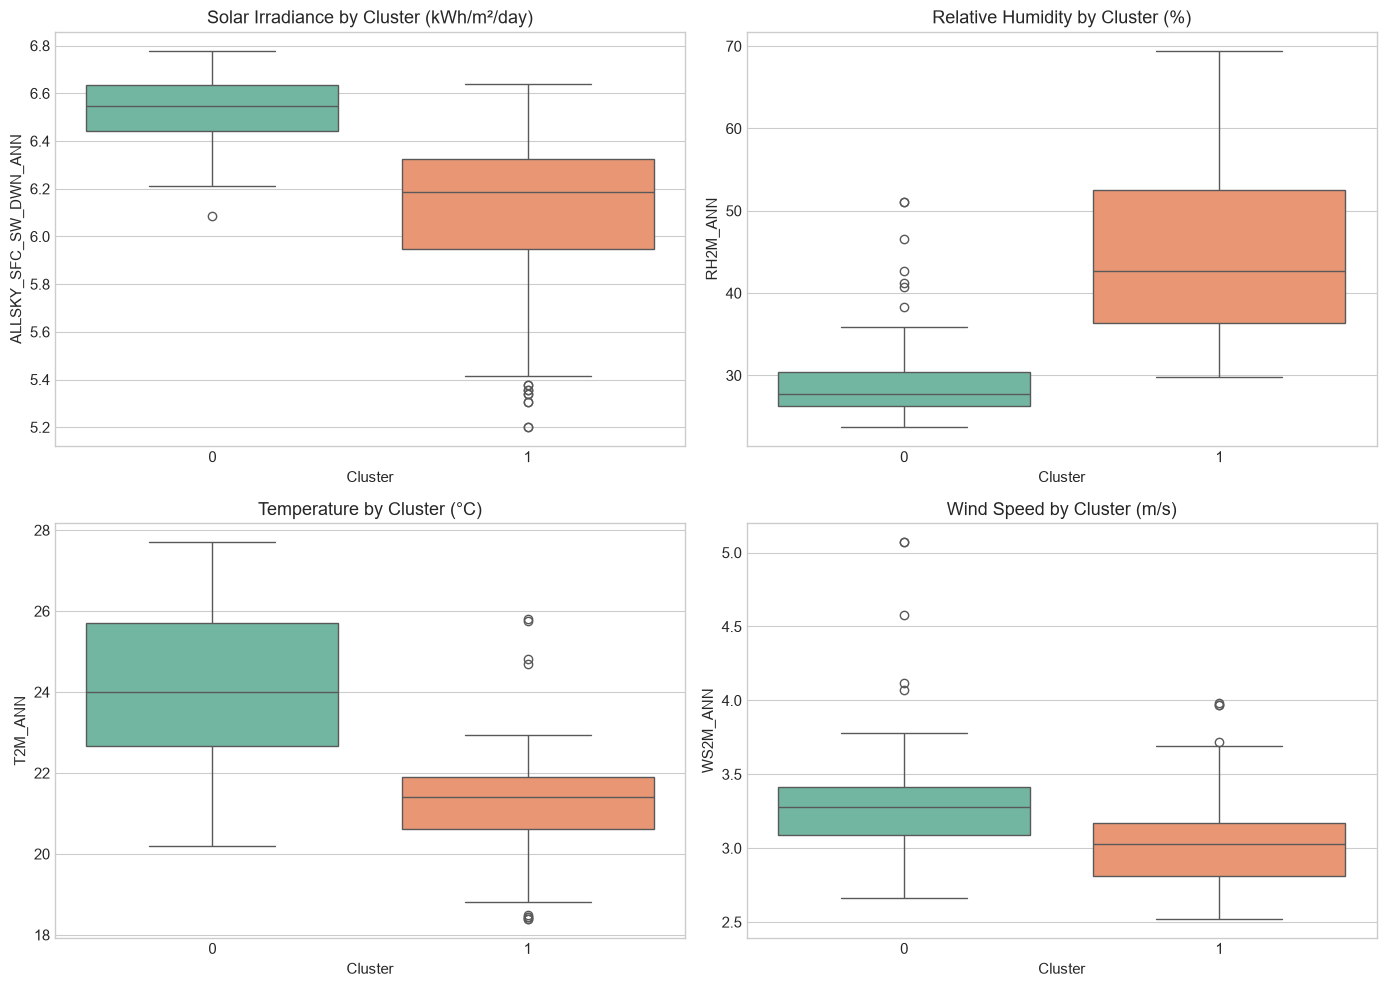

In [13]:
# Visualizing Cluster Differences with df_clean
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='Cluster', y='ALLSKY_SFC_SW_DWN_ANN', data=df_clean, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Solar Irradiance by Cluster (kWh/m²/day)')

sns.boxplot(x='Cluster', y='RH2M_ANN', data=df_clean, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Relative Humidity by Cluster (%)')

sns.boxplot(x='Cluster', y='T2M_ANN', data=df_clean, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Temperature by Cluster (°C)')

sns.boxplot(x='Cluster', y='WS2M_ANN', data=df_clean, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Wind Speed by Cluster (m/s)')

plt.tight_layout()
plt.show()


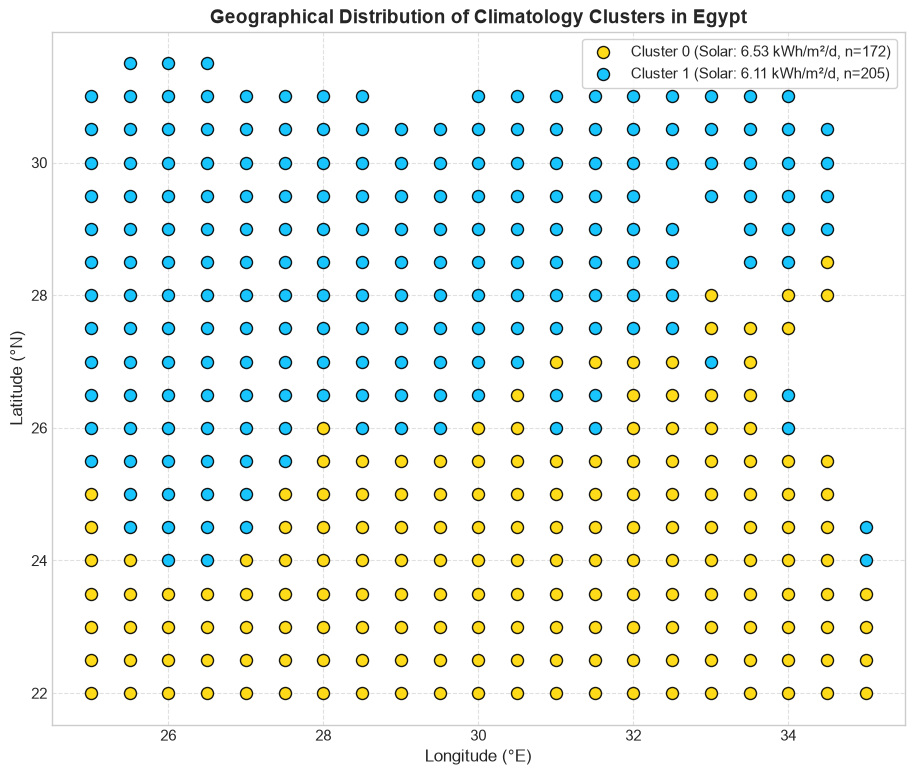

In [14]:
# 2D Geographical Plot of Egypt Clusters using df_clean
plt.figure(figsize=(11, 9))

colors = ['gold', 'deepskyblue', 'crimson', 'forestgreen']
clusters = sorted(df_clean['Cluster'].unique())

for c in clusters:
    subset = df_clean[df_clean['Cluster'] == c]
    mean_solar = subset['ALLSKY_SFC_SW_DWN_ANN'].mean()
    plt.scatter(
        subset['longitude'], 
        subset['latitude'], 
        label=f'Cluster {c} (Solar: {mean_solar:.2f} kWh/m²/d, n={len(subset)})',
        c=colors[c % len(colors)],
        s=75,
        edgecolors='black',
        alpha=0.9
    )

plt.xlabel('Longitude (°E)', fontsize=12)
plt.ylabel('Latitude (°N)', fontsize=12)
plt.title('Geographical Distribution of Climatology Clusters in Egypt', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [15]:
# Analyzing Geographic Boundaries & Recommending Best Cluster
print("=== Geographical Region Summary per Cluster ===")

best_cluster_id = cluster_profile['ALLSKY_SFC_SW_DWN_ANN'].idxmax()

for c in sorted(df_clean['Cluster'].unique()):
    sub = df_clean[df_clean['Cluster'] == c]
    lat_min, lat_max = sub['latitude'].min(), sub['latitude'].max()
    lon_min, lon_max = sub['longitude'].min(), sub['longitude'].max()
    solar_avg = sub['ALLSKY_SFC_SW_DWN_ANN'].mean()
    rh_avg = sub['RH2M_ANN'].mean()
    temp_avg = sub['T2M_ANN'].mean()
    
    is_best = " (BEST SOLAR REGION ★)" if c == best_cluster_id else ""
    print(f"\n--- Cluster {c}{is_best} ---")
    print(f"Number of Locations: {len(sub)}")
    print(f"Latitude Range: {lat_min}°N to {lat_max}°N | Longitude Range: {lon_min}°E to {lon_max}°E")
    print(f"Average Solar Irradiance: {solar_avg:.3f} kWh/m²/day")
    print(f"Average Relative Humidity: {rh_avg:.2f}% | Average Temp: {temp_avg:.2f}°C")

print(f"\n=======================================================")
print(f"OPTIMAL CLUSTER RECOMMENDATION FOR SOLAR PROJECTS")
print(f"Recommended Cluster: Cluster {best_cluster_id}")
print(f"Solar Irradiance Potential: {cluster_profile.loc[best_cluster_id, 'ALLSKY_SFC_SW_DWN_ANN']:.3f} kWh/m²/day")
print(f"Relative Humidity: {cluster_profile.loc[best_cluster_id, 'RH2M_ANN']:.2f}%")
print(f"Key Advantages: Maximum solar radiation intensity, clear skies, and low humidity.")
print(f"=======================================================")

# Save Cluster 0 candidates for Phase 2 using df_clean
candidate_df = df_clean[df_clean['Cluster'] == best_cluster_id][['latitude', 'longitude', 'ALLSKY_SFC_SW_DWN_ANN', 'RH2M_ANN', 'T2M_ANN', 'WS2M_ANN']].copy()
candidate_df.to_csv('phase1_cluster0_candidates.csv', index=False)
print("Saved Cluster 0 candidate locations from df_clean to 'phase1_cluster0_candidates.csv' for Phase 2!")


=== Geographical Region Summary per Cluster ===

--- Cluster 0 (BEST SOLAR REGION ★) ---
Number of Locations: 172
Latitude Range: 22.0°N to 28.5°N | Longitude Range: 25.0°E to 35.0°E
Average Solar Irradiance: 6.526 kWh/m²/day
Average Relative Humidity: 28.83% | Average Temp: 24.12°C

--- Cluster 1 ---
Number of Locations: 205
Latitude Range: 24.0°N to 31.5°N | Longitude Range: 25.0°E to 35.0°E
Average Solar Irradiance: 6.108 kWh/m²/day
Average Relative Humidity: 44.91% | Average Temp: 21.25°C

OPTIMAL CLUSTER RECOMMENDATION FOR SOLAR PROJECTS
Recommended Cluster: Cluster 0
Solar Irradiance Potential: 6.526 kWh/m²/day
Relative Humidity: 28.83%
Key Advantages: Maximum solar radiation intensity, clear skies, and low humidity.
Saved Cluster 0 candidate locations from df_clean to 'phase1_cluster0_candidates.csv' for Phase 2!
